In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.api as smt

from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller

In [2]:
sales_of_company_x = pd.read_csv("1._Лекция_tsml/Series/monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("1._Лекция_tsml/Series/monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("1._Лекция_tsml/Series/international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("1._Лекция_tsml/Series/mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("1._Лекция_tsml/Series/weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("1._Лекция_tsml/Series/daily-total-female-births-in-cal.csv")

In [3]:
all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers["Count"],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]
}

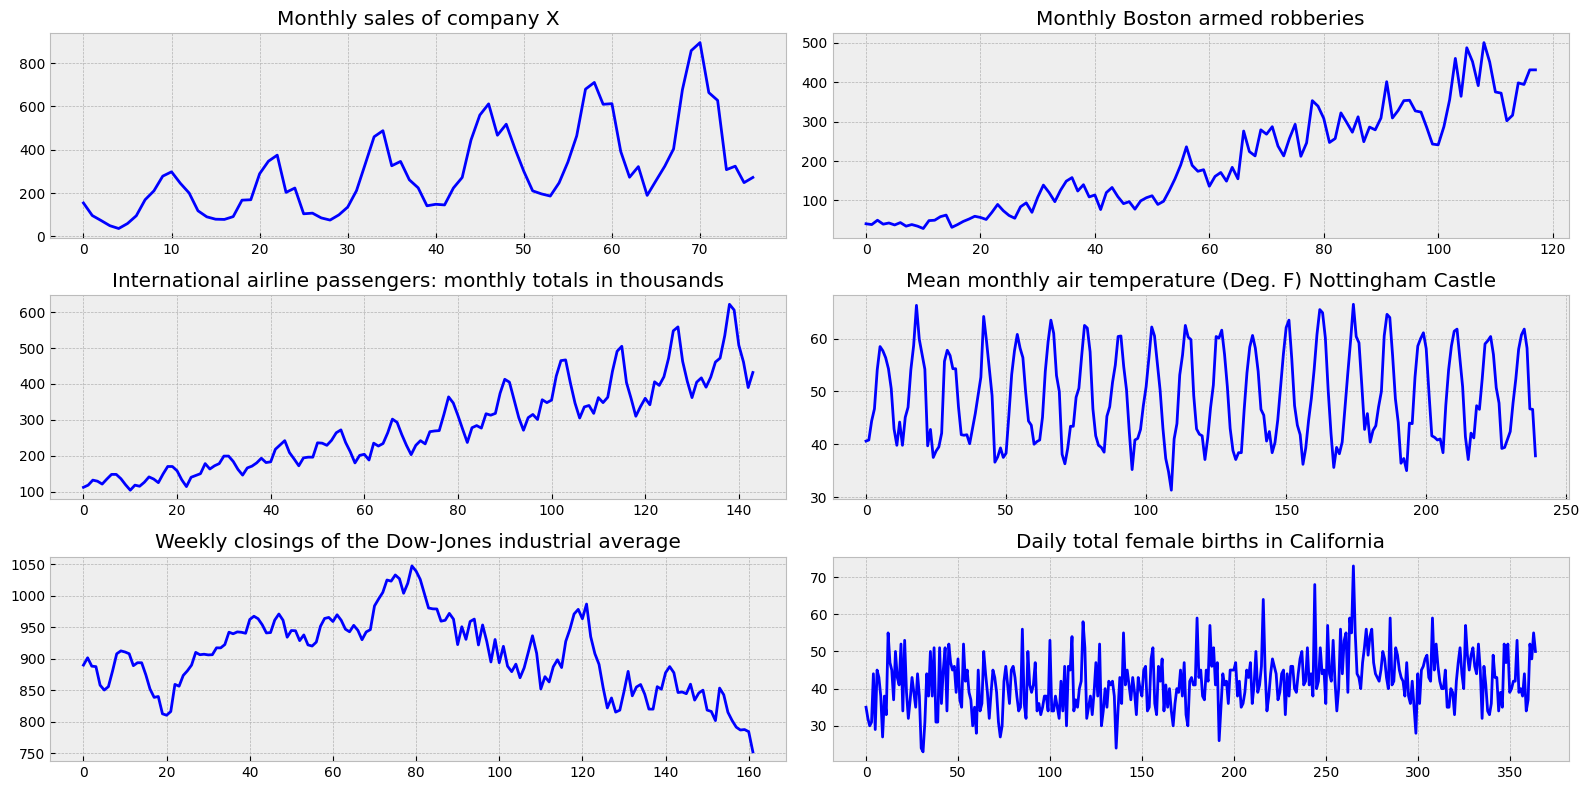

In [4]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 8))
    layout = (3, 2)
    for i, key in enumerate(all_series.keys()):
        x = i % 2
        y = int((i - x) / 2)

        ts_ax = plt.subplot2grid(layout, (y, x))
        all_series[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)

    plt.tight_layout()

In [5]:
################
 # Dickey-Fuller
##################
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    return dftest[1]  # p-value

In [6]:
def tsplot(y, lags=24, figsize=(14, 8), style='bmh', title=''):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (3, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0))
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (2, 0))

        y.plot(ax=ts_ax, color='blue')
        ts_ax.set_title(f'{title} — ряд')

        smt.graphics.plot_acf(y.dropna(), lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y.dropna(), lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()
        plt.show()

Обработка Monthly sales of company X
Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


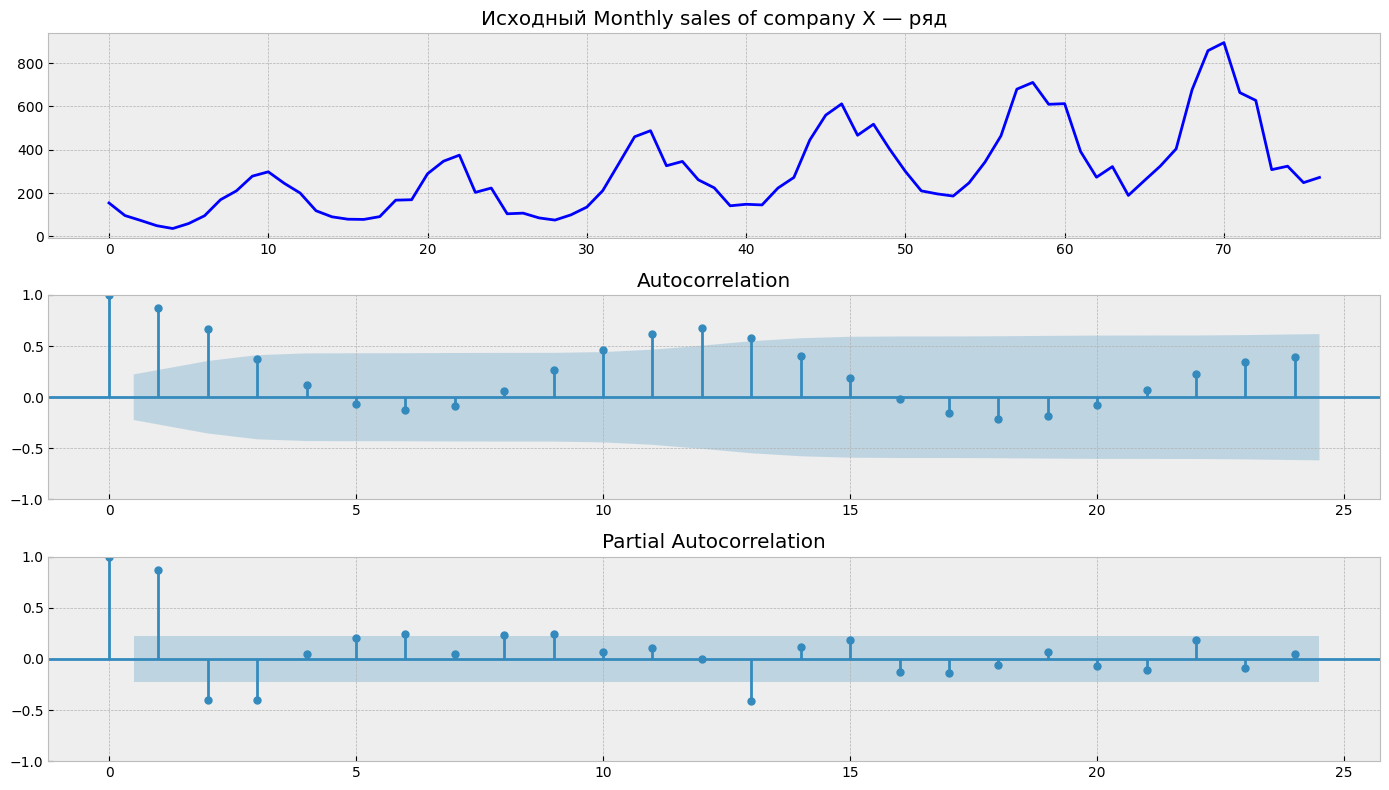

Box-Cox применен, λ=0.211
Results of Dickey-Fuller Test:
Test Statistic                 -0.631279
p-value                         0.863757
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64
Сделано 1-е дифференцирование
Results of Dickey-Fuller Test:
Test Statistic                 -3.284204
p-value                         0.015599
#Lags Used                     11.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


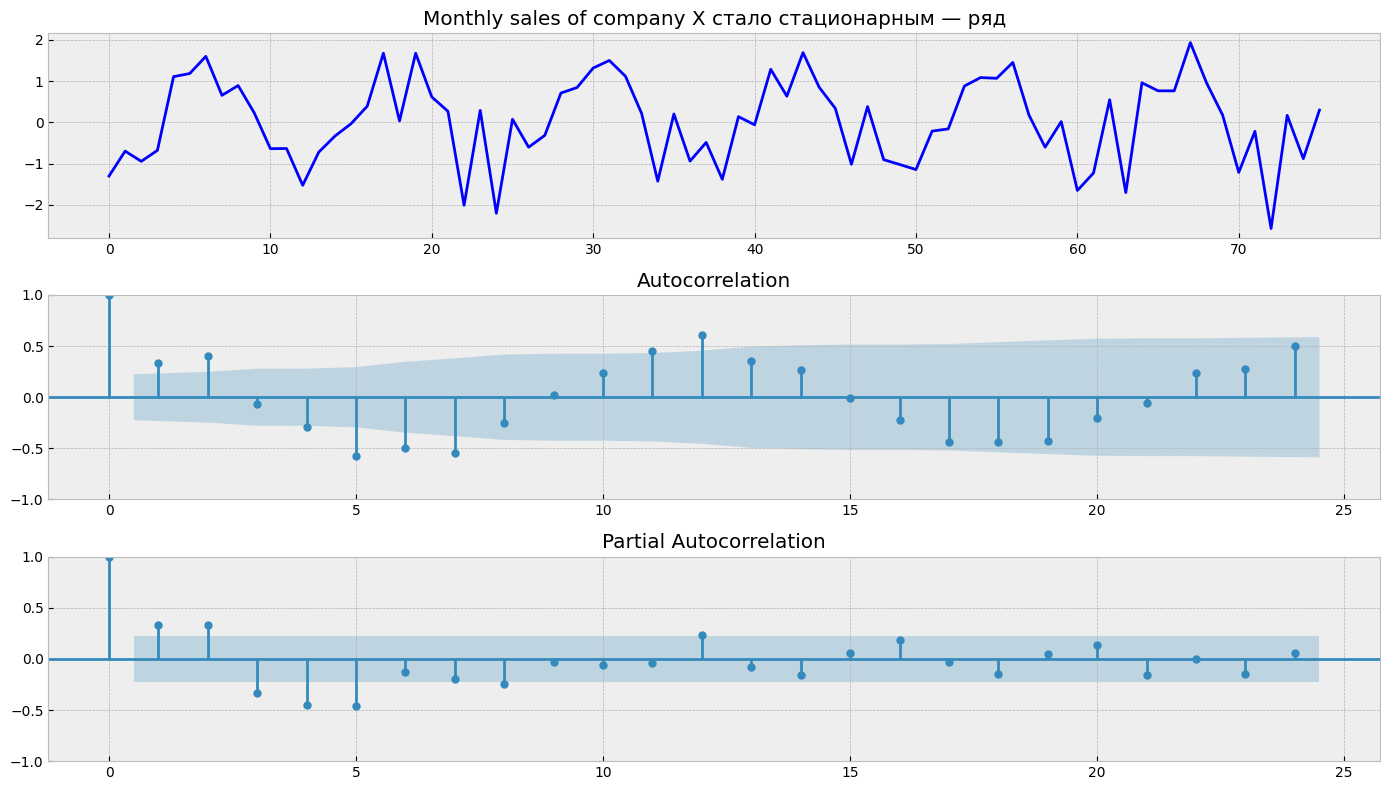

Обработка Monthly Boston armed robberies
Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


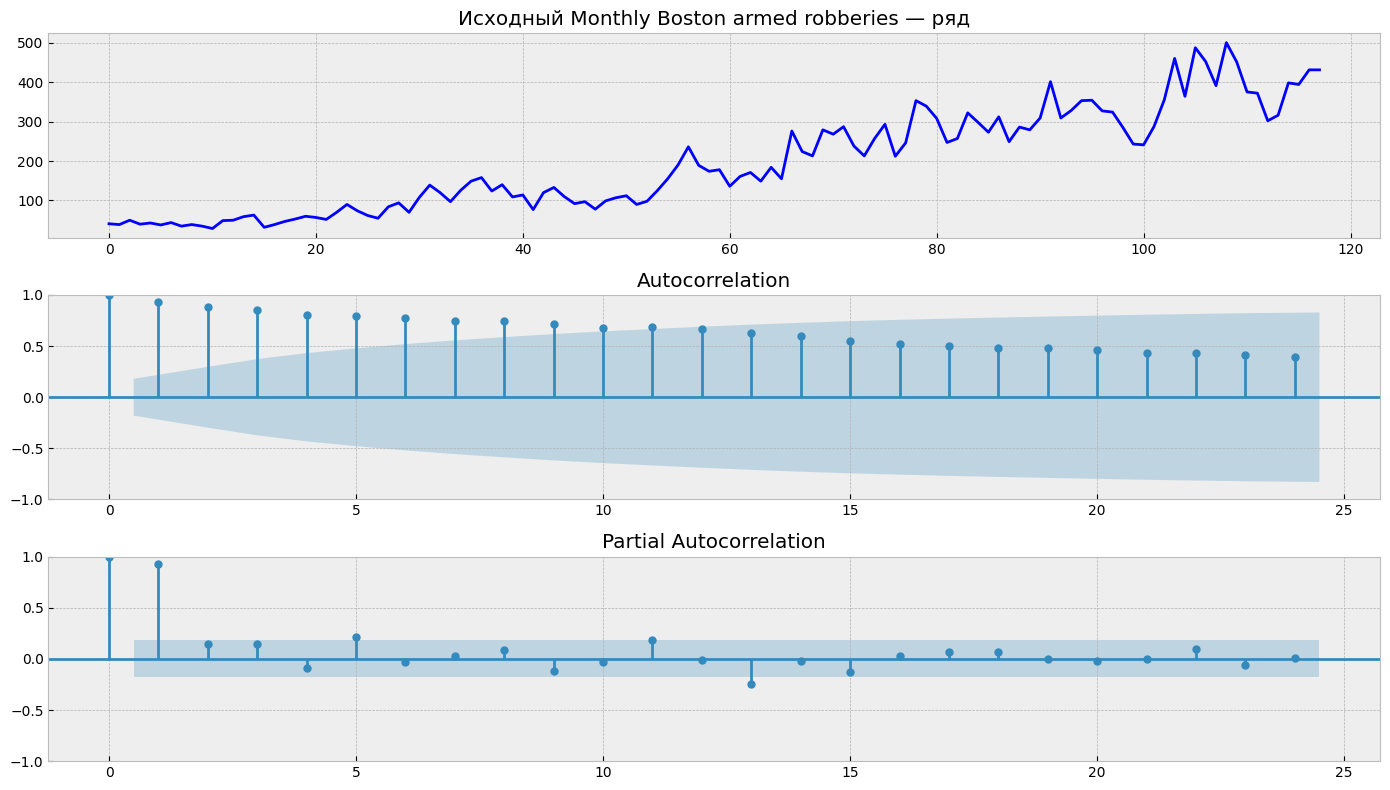

Box-Cox применен, λ=0.317
Results of Dickey-Fuller Test:
Test Statistic                  -0.876346
p-value                          0.795662
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64
Сделано 1-е дифференцирование
Results of Dickey-Fuller Test:
Test Statistic                -5.862061e+00
p-value                        3.392204e-07
#Lags Used                     1.000000e+01
Number of Observations Used    1.060000e+02
Critical Value (1%)           -3.493602e+00
Critical Value (5%)           -2.889217e+00
Critical Value (10%)          -2.581533e+00
dtype: float64


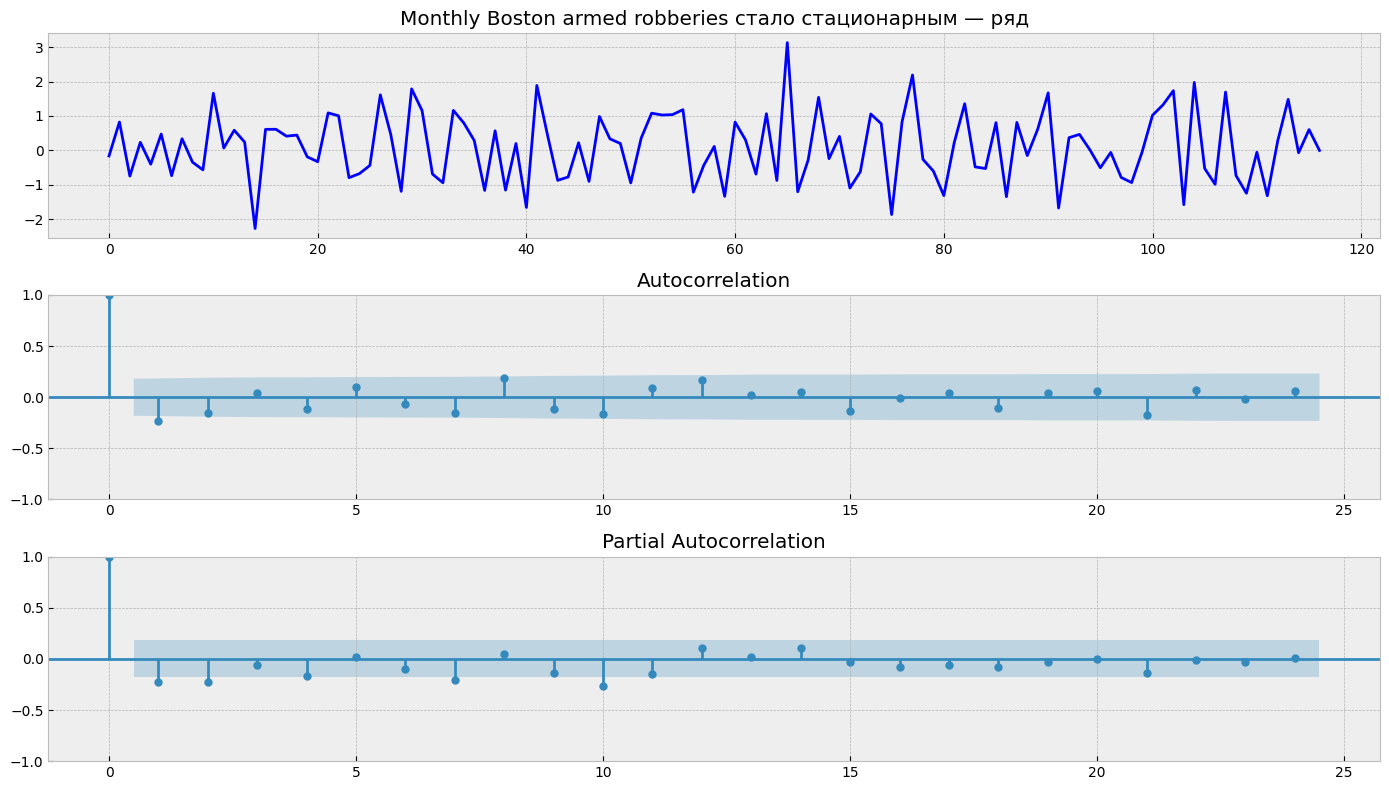

Обработка International airline passengers: monthly totals in thousands
Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


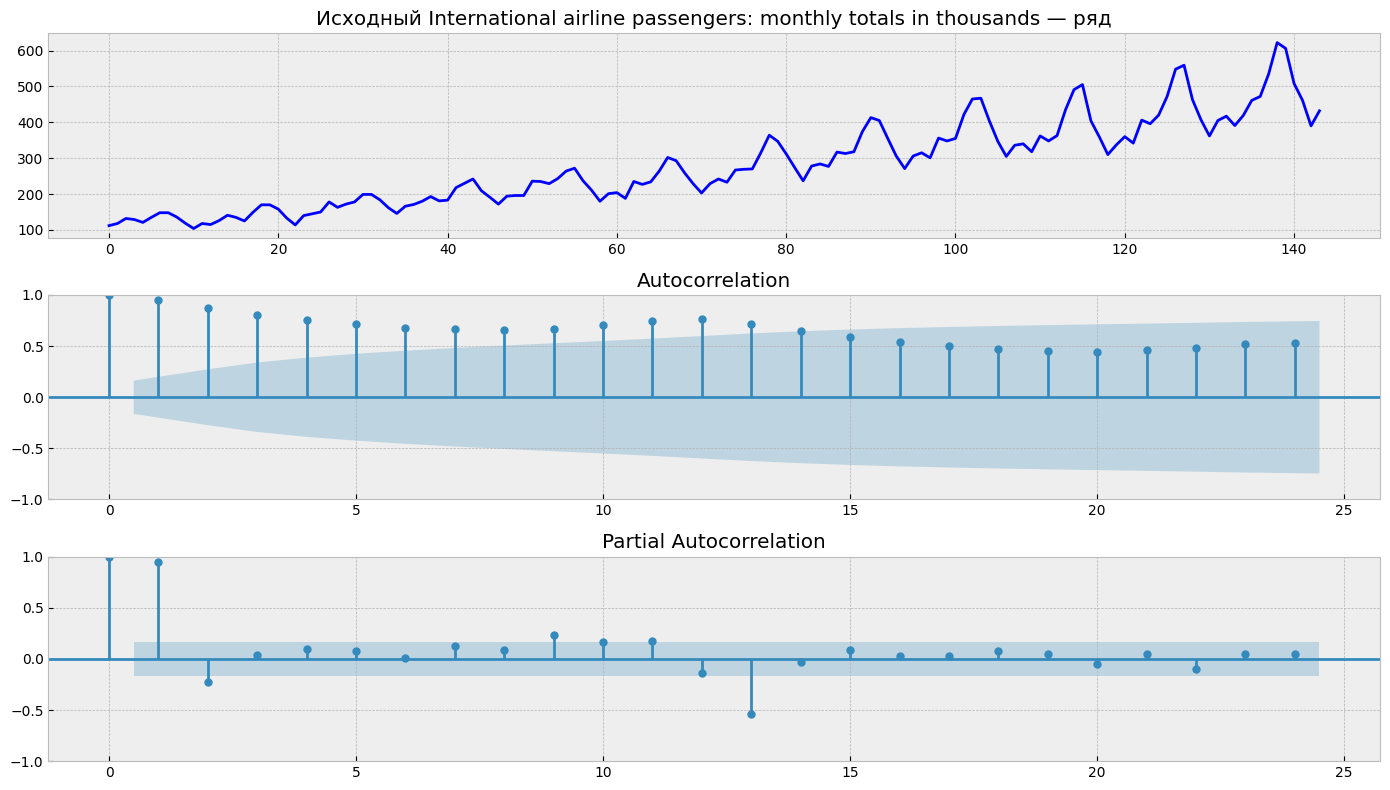

Box-Cox применен, λ=0.148
Results of Dickey-Fuller Test:
Test Statistic                  -1.326071
p-value                          0.617162
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Сделано 1-е дифференцирование
Results of Dickey-Fuller Test:
Test Statistic                  -2.871708
p-value                          0.048738
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


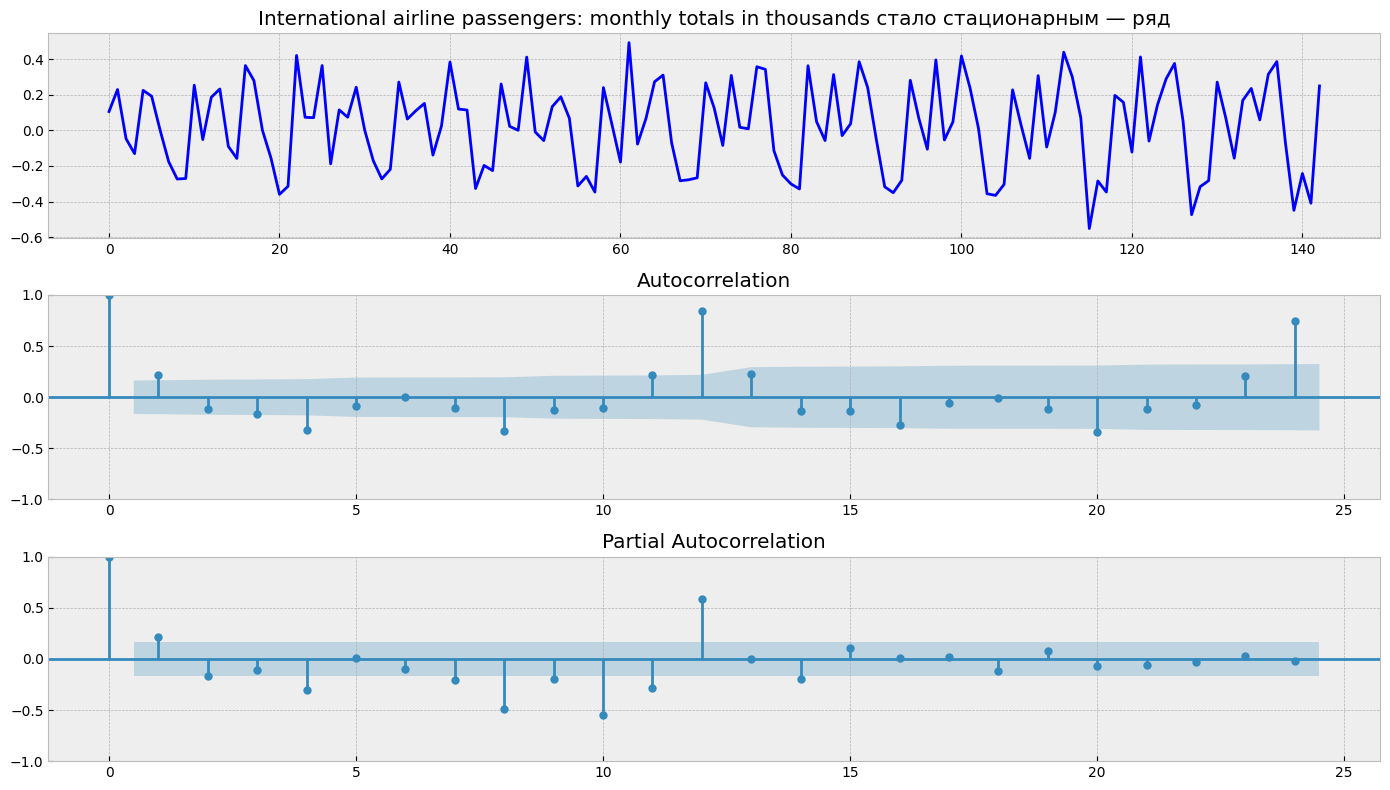

Обработка Mean monthly air temperature (Deg. F) Nottingham Castle
Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64


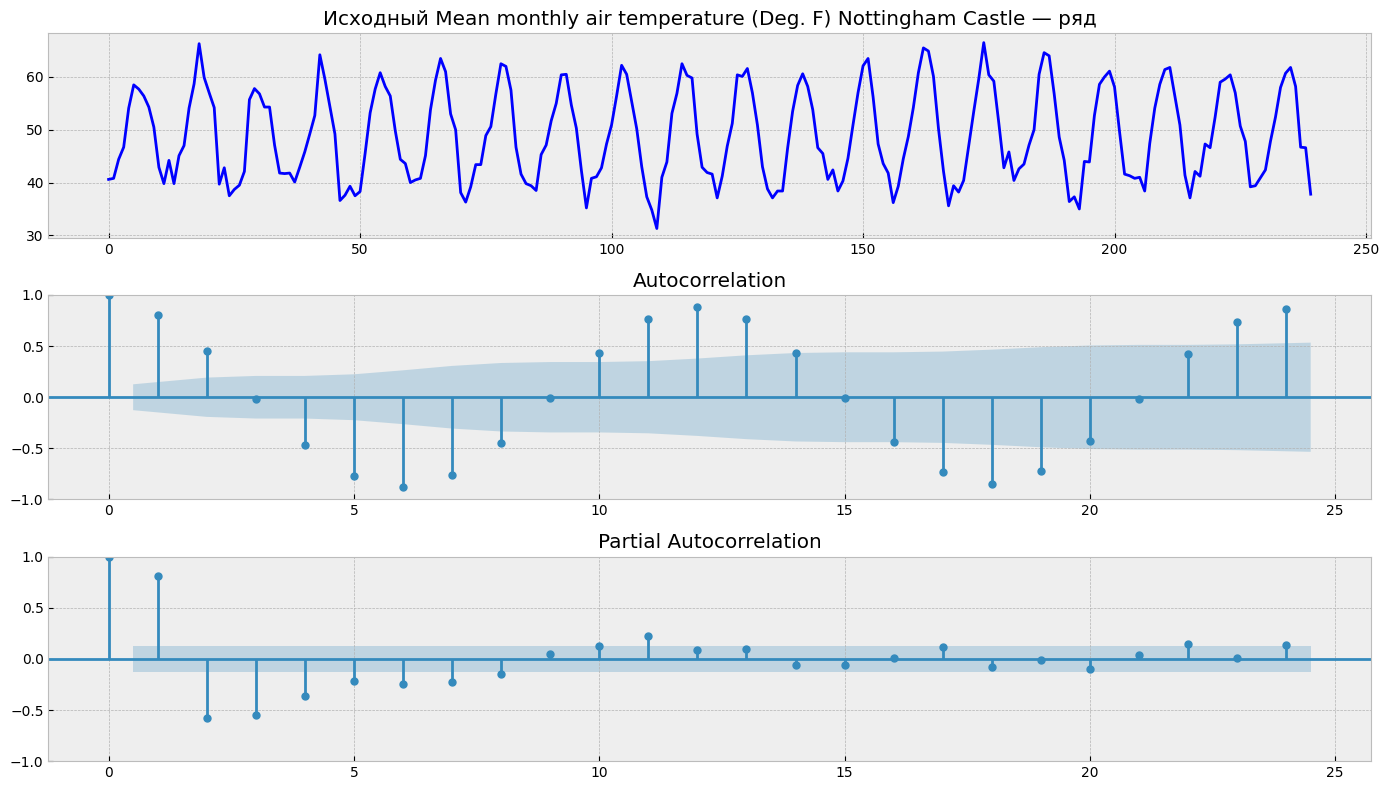

Box-Cox применен, λ=0.066
Results of Dickey-Fuller Test:
Test Statistic                  -3.736591
p-value                          0.003627
#Lags Used                      15.000000
Number of Observations Used    224.000000
Critical Value (1%)             -3.459885
Critical Value (5%)             -2.874531
Critical Value (10%)            -2.573694
dtype: float64


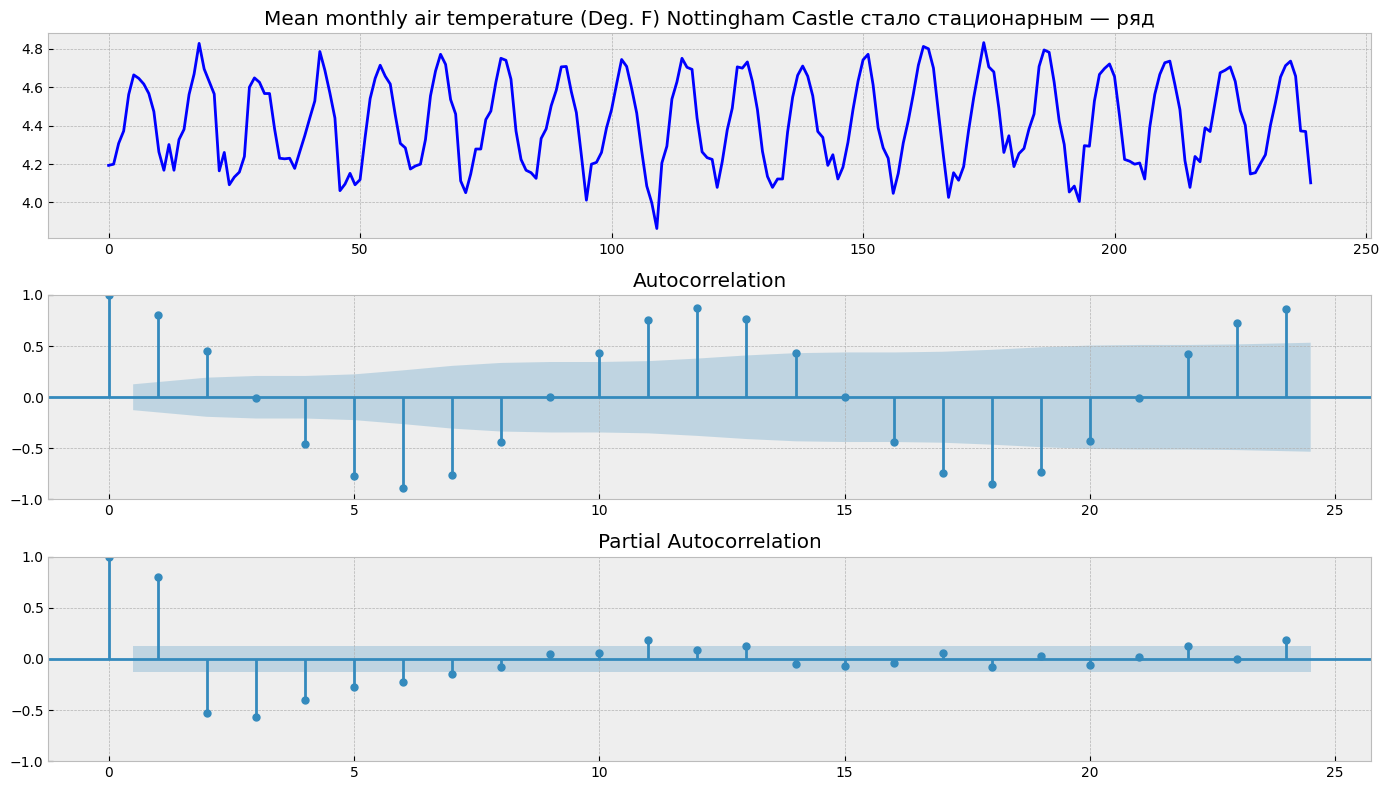

Обработка Weekly closings of the Dow-Jones industrial average
Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64


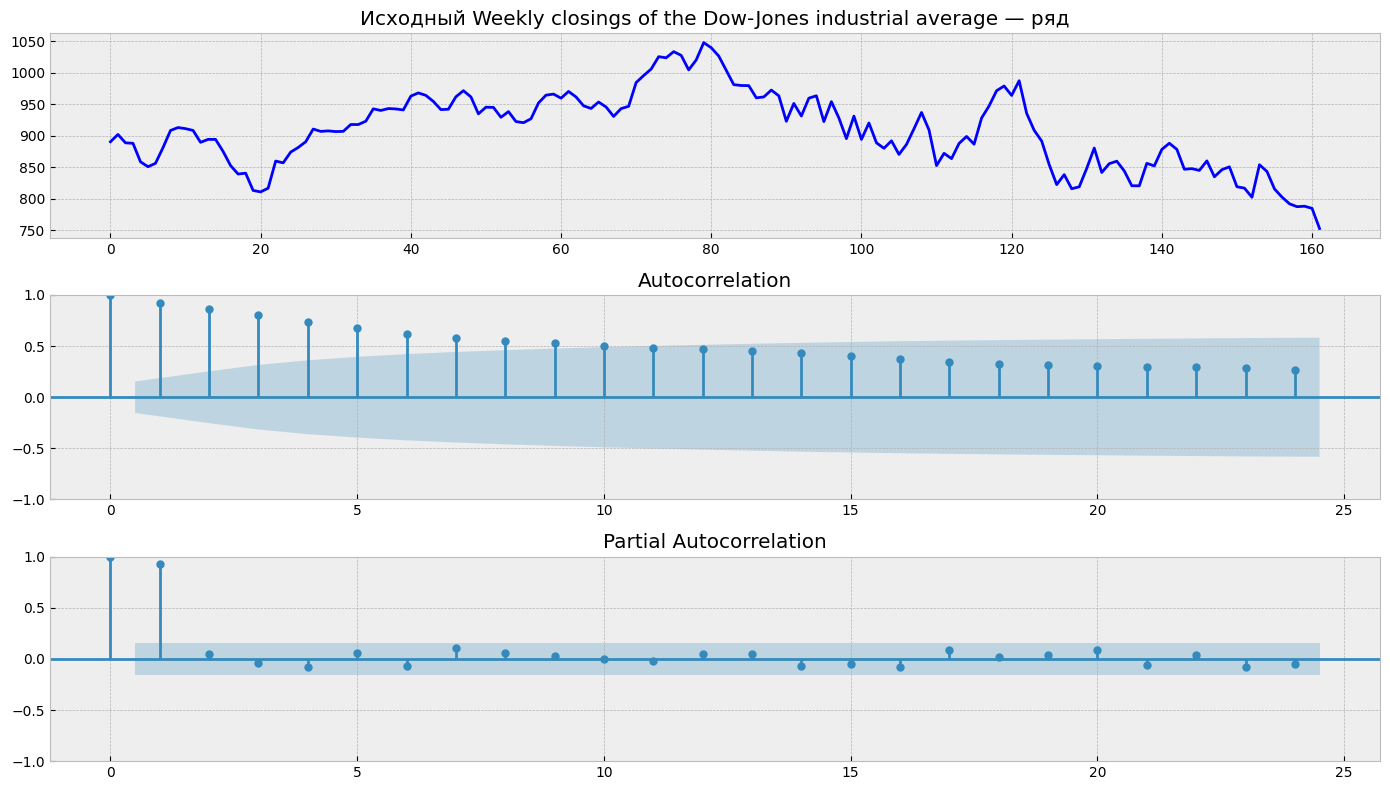

Box-Cox применен, λ=1.133
Results of Dickey-Fuller Test:
Test Statistic                  -1.327773
p-value                          0.616372
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64
Сделано 1-е дифференцирование
Results of Dickey-Fuller Test:
Test Statistic                -1.302750e+01
p-value                        2.382691e-24
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64


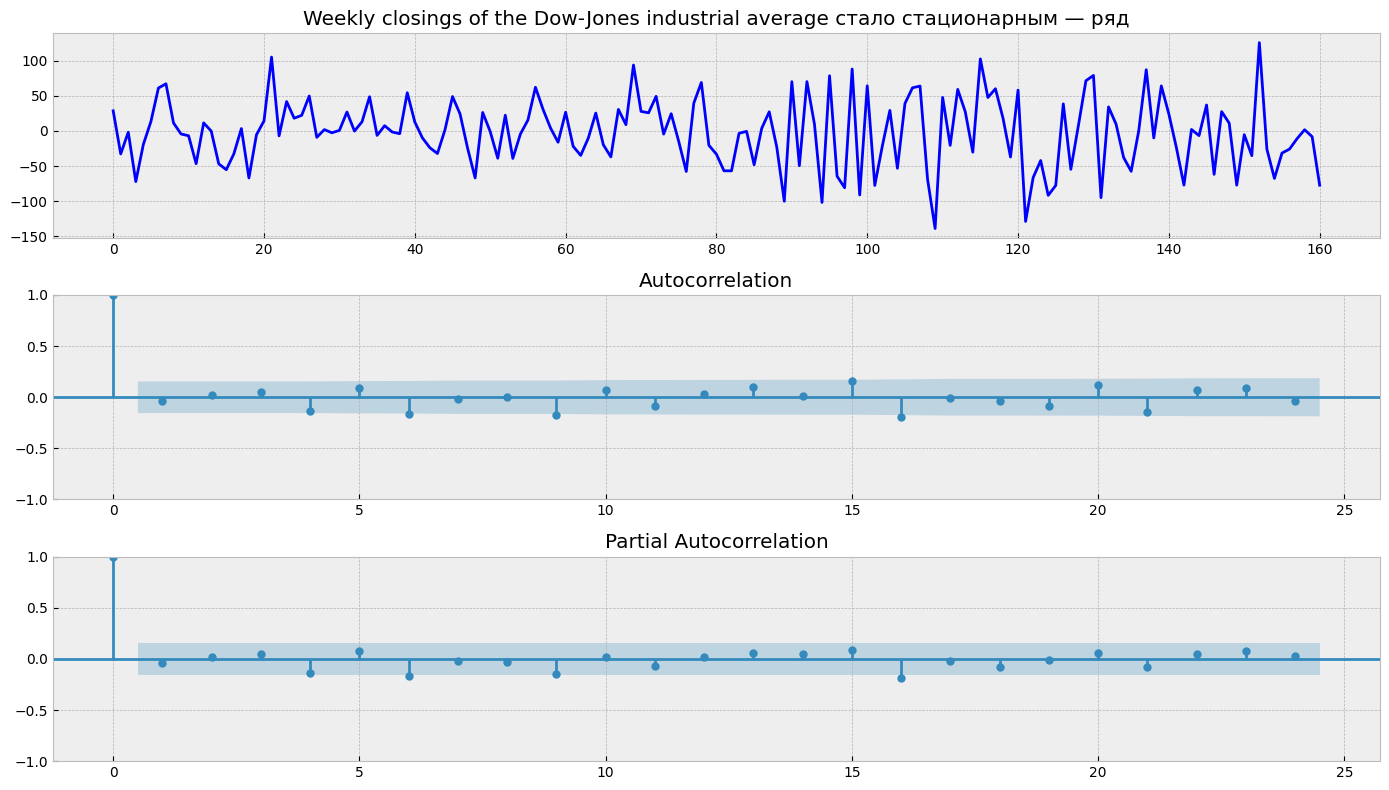

Обработка Daily total female births in California
Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64


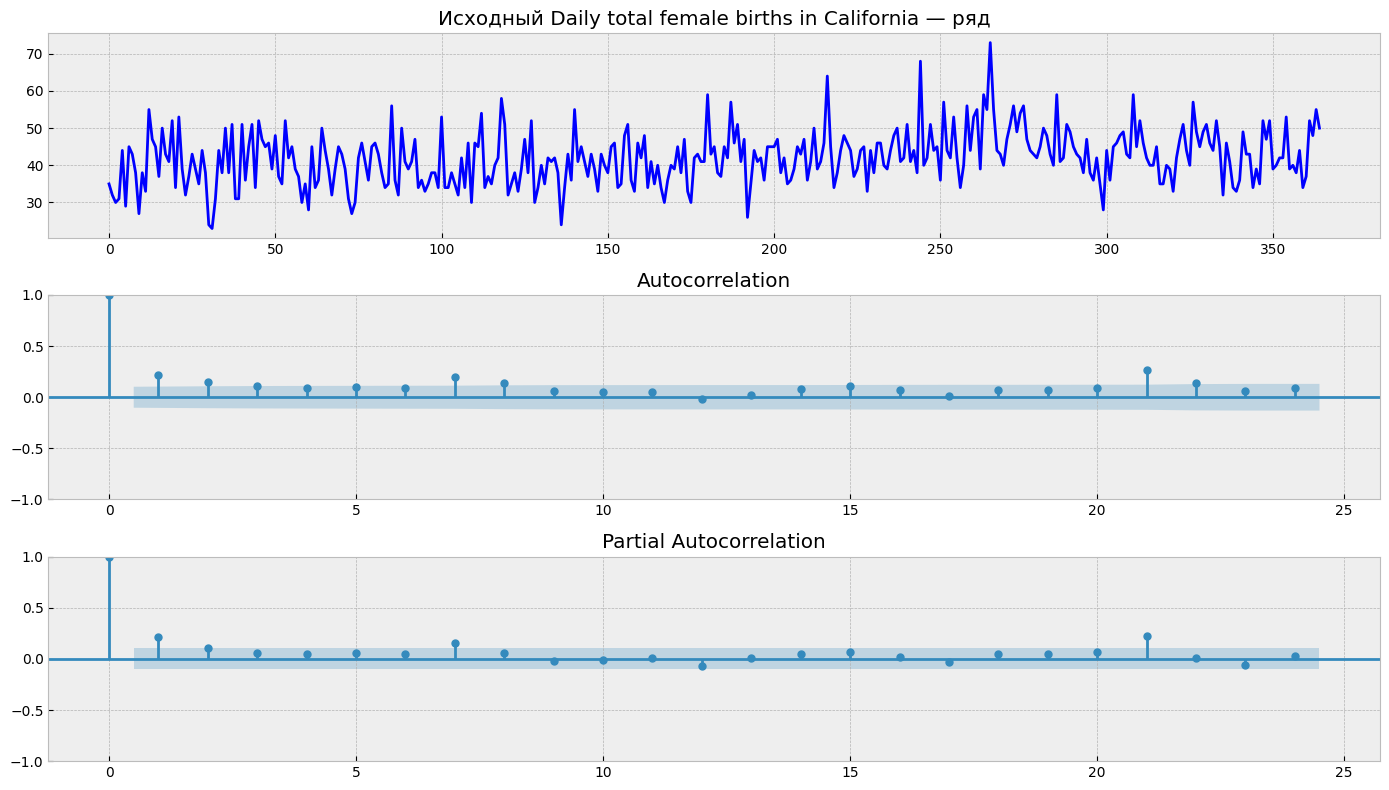

Box-Cox применен, λ=0.290
Results of Dickey-Fuller Test:
Test Statistic                  -4.344294
p-value                          0.000372
#Lags Used                       7.000000
Number of Observations Used    357.000000
Critical Value (1%)             -3.448801
Critical Value (5%)             -2.869670
Critical Value (10%)            -2.571101
dtype: float64


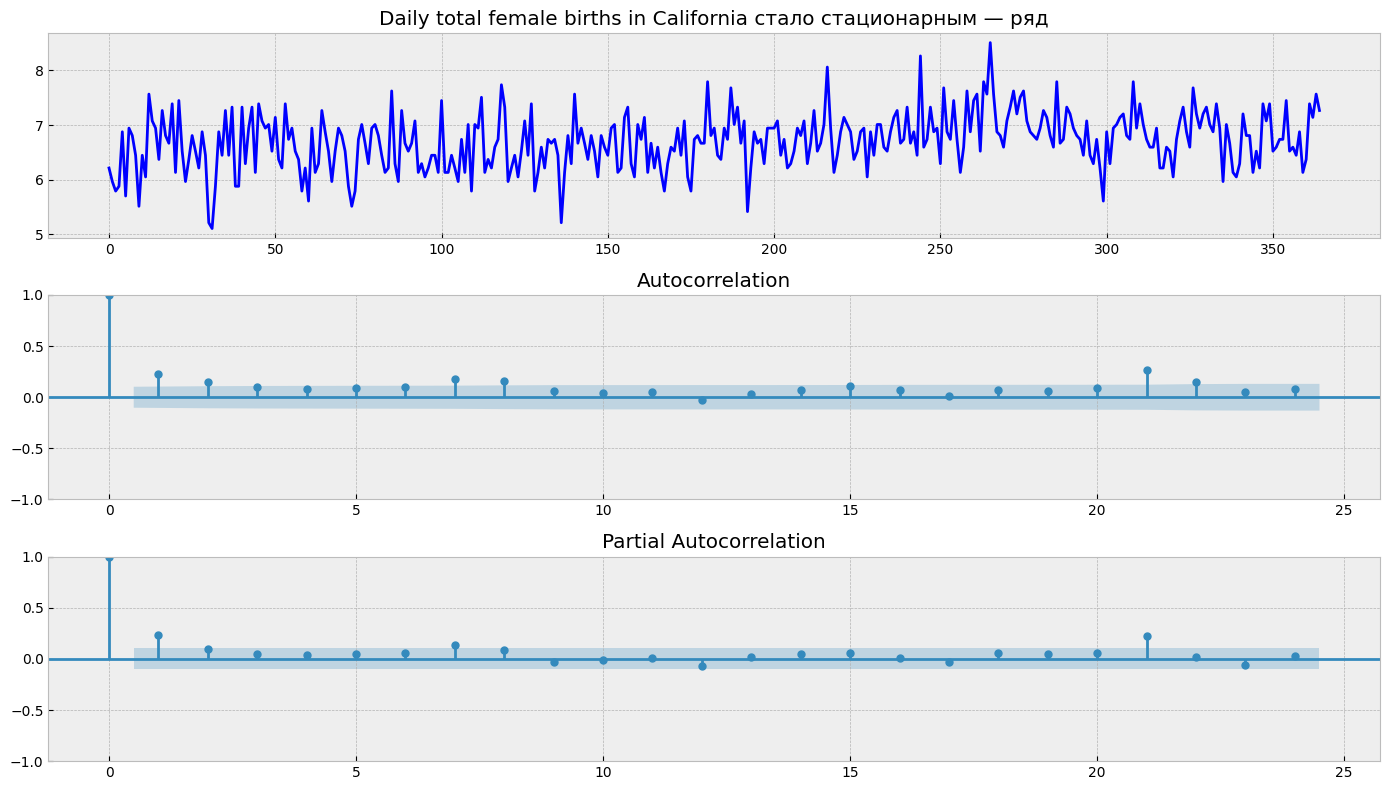

In [7]:
stationary_series = {}

for name, series in all_series.items():
    print(f'Обработка {name}')

    ts = series.copy()

    # 1. Проверяем исходный ряд
    test_stationarity(ts)
    tsplot(ts, title=f'Исходный {name}')

    # 2. Box-Cox трансформация (если все значения > 0)
    if (ts > 0).all():
        ts, lmbda = boxcox(ts)
        ts = pd.Series(ts)
        print(f'Box-Cox применен, λ={lmbda:.3f}')

    # 3. Дифференцирование (до 2 раз максимум)
    diff_count = 0
    while test_stationarity(pd.Series(ts)) > 0.05 and diff_count < 2:
        ts = np.diff(ts, 1)
        ts = pd.Series(ts)
        diff_count += 1
        print(f'Сделано {diff_count}-е дифференцирование')

    # 4. Сохраняем результат
    stationary_series[name] = ts
    tsplot(ts, title=f'{name} стало стационарным')